In [27]:
import gzip
import os
import math

from functools import partial
from pathlib import Path
from shutil import rmtree
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from adam_atan2_pytorch import MuonAdamAtan2
from axial_positional_embedding import ContinuousAxialPositionalEmbedding
from beartype import beartype
from beartype.door import is_bearable
from ema_pytorch import EMA
from rotary_embedding_torch import RotaryEmbedding, apply_rotary_emb
from torch import nn, tensor, cat
from torch.nn import Linear, Module, ModuleList
from torch.utils.data import DataLoader, Dataset
from torchdiffeq import odeint
from torchvision.utils import save_image
from transfusion_pytorch import Transfusion, print_modality_sample
from einops import rearrange, repeat, reduce, einsum, pack, unpack
from einops.layers.torch import Rearrange

# Local/Internal project imports
from vot_utils.data import DATA_DIRECTORY
from references.transfusion_pytorch.transfusion_pytorch.transfusion import (
    Transformer,
    ModalityInfo,
    GetPredFlows,
    add_temp_batch_dim,
    append_dims,
    cast_tuple,
    char_tokenize,
    decode_chars,
    default,
    default_to_modality_shape_fn,
    default_modality_length_to_time_fn,
    modality_positions_to_is_modality_mask,
    modality_positions_to_tensor,
    order_modality_positions_by_seq_offset,
    exists,
    get_model_output_to_flow_fn,
    identity,
    pack_one_with_inverse,
    is_tensor,
    is_empty,
    tree_map_tensor,
    apply_fn_modality_type,
    join,
    stack,
    derive_rotary_positions_from_modality_positions,
    pad_sequence,
    typecheck
)

In [28]:
# Instead of calculating num_modalities and times and reshaping to (modality_number, modality)
# Pass it from the beginning

In [29]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

In [30]:
# constants

IMAGE_AFTER_TEXT = True   # False for captioning, True for text-to-image
USE_PROMPT = False        # whether to use prompting, or synthesize from start token
NUM_TRAIN_STEPS = 20_000
SAMPLE_EVERY = 500
CHANNEL_FIRST = True

In [31]:
# functions

def divisible_by(num, den):
    return (num % den) == 0

def plot_batch(images):
    # Create a grid to display them neatly (e.g., 8 images per row)
    grid_img = torchvision.utils.make_grid(images, nrow=8)

    # PyTorch image tensors are (Channels, Height, Width).
    # Matplotlib expects (Height, Width, Channels), so we permute the dimensions.
    grid_img_np = grid_img.permute(1, 2, 0).numpy()

    # Plot the grid
    plt.figure(figsize=(10, 5))
    plt.imshow(grid_img_np, cmap='gray')
    plt.axis('off')
    plt.title("Sample MNIST Batch")
    plt.show()

def plot_batch_with_labels(batch, nrow=8):
    # Unzip the list of tuples: [(l, i), (l, i)] -> (labels, images)
    labels, images = zip(*batch)
    
    batch_size = len(images)
    num_rows = (batch_size + nrow - 1) // nrow
    
    # Create the figure
    fig, axes = plt.subplots(num_rows, nrow, figsize=(nrow * 1.5, num_rows * 1.5))
    axes = axes.flatten()

    for i in range(len(axes)):
        if i < batch_size:
            # images[i] is likely a tensor; permute for matplotlib (C, H, W) -> (H, W, C)
            img = images[i].permute(1, 2, 0).numpy()
            
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f"Label: {labels[i]}", fontsize=9)
            axes[i].axis('off')
        else:
            # Hide extra subplots if batch size isn't a perfect multiple of nrow
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [32]:
# encoder / decoder

class Encoder(Module):
    def forward(self, x):
        x = rearrange(x, '... 1 (h p1) (w p2) -> ... h w (p1 p2)', p1 = 2, p2 = 2)

        if CHANNEL_FIRST:
            x = rearrange(x, 'b ... d -> b d ...')

        return x * 2 - 1

class Decoder(Module):
    def forward(self, x):

        if CHANNEL_FIRST:
            x = rearrange(x, 'b d ... -> b ... d')

        x = rearrange(x, '... h w (p1 p2) -> ... 1 (h p1) (w p2)', p1 = 2, p2 = 2)
        return ((x + 1) * 0.5).clamp(min = 0., max = 1.)

In [33]:
class MnistDataset(Dataset):
    def __init__(self, download=False):
        self.mnist = torchvision.datasets.MNIST(
            DATA_DIRECTORY,
            download=download
        )
    
    def __len__(self):
        return len(self.mnist)
    
    def __getitem__(self, idx):
        pil, labels = self.mnist[idx]
        digit_tensor = T.PILToTensor()(pil)
        output =  tensor(labels), (digit_tensor / 255).float()

        if IMAGE_AFTER_TEXT:
            return output

        first, second = output
        return second, first
    
def cycle(iter_dl):
    while True:
        for batch in iter_dl:
            yield batch

def collate_fn(data):
    data = [*map(list, data)]
    return data

In [34]:
@typecheck
def create_dataloader(dataset: Dataset, **kwargs) -> DataLoader:
    return DataLoader(dataset, collate_fn = collate_fn, **kwargs)

dataset = MnistDataset()
dataloader = create_dataloader(dataset, batch_size = 16, shuffle = True)
iter_dl = cycle(dataloader)

In [35]:
# optimizer = MuonAdamAtan2(model.muon_parameters(), model.parameters(), lr = 8e-4)

# accelerator = Accelerator()

# model, optimizer, dataloader = accelerator.prepare(model, optimizer, dataloader)

# ema_model.to(accelerator.device)


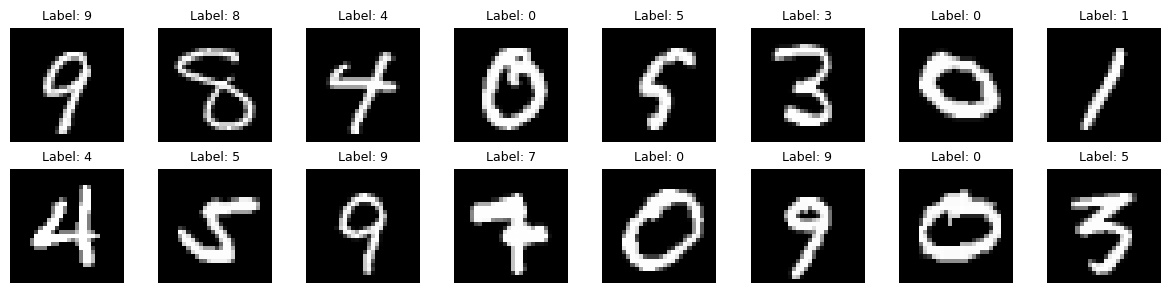

In [36]:
plot_batch_with_labels(next(iter_dl))

#### Manual Run

In [269]:
batch = next(iter_dl)

In [300]:
next(iter_dl)

[[tensor(1),
  tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.00

In [270]:
num_text_tokens = 10
dim_latent = 4
channel_first_latent = CHANNEL_FIRST
modality_default_shape = (14, 14)
modality_encoder = Encoder()
modality_decoder = Decoder()
add_pos_emb = True
modality_num_dim = 2

velocity_consistency_loss_weight = 0.1
reconstruction_loss_weight = 0.1
model_output_clean = True
transformer = dict(dim=64, depth=4, dim_head=32, heads=8, attn_laser=True)

to_modality_shape_fn = default_to_modality_shape_fn
fallback_to_default_shape_if_invalid = False
modality_encoder_decoder_requires_batch_dim = True
pre_post_transformer_enc_dec = None

ignore_index = -1
flow_loss_weight = 1.
text_loss_weight = 1.

odeint_kwargs = dict(
    atol = 1e-5,
    rtol = 1e-5,
    method = 'midpoint'
)
eps = 1e-2
prob_uncond = 0.1

In [271]:
if isinstance(transformer, dict):
    transformer = Transformer(**transformer).to(device)

dim = transformer.dim
dim_latent = default(dim_latent, dim)

In [272]:
dim_latents = cast_tuple(dim_latent)
num_modalities = len(dim_latents)
channel_first_latent = cast_tuple(channel_first_latent, num_modalities)
to_modality_shape_fn = cast_tuple(to_modality_shape_fn, num_modalities)

if not exists(modality_default_shape) or is_bearable(modality_default_shape, tuple[int, ...]):
    modality_default_shape = (modality_default_shape,) * num_modalities

modality_num_dim = cast_tuple(modality_num_dim, num_modalities)
add_pos_emb = cast_tuple(add_pos_emb, num_modalities)


In [273]:
pos_emb_mlp = ModuleList([])

for modality_add_pos_emb, modality_ndim in zip(add_pos_emb, modality_num_dim):
    if not modality_add_pos_emb:
        pos_emb_mlp.append(None)
        continue

    pos_generating_mlp = ContinuousAxialPositionalEmbedding(
        dim = dim,
        num_axial_dims = modality_ndim,
    )

    pos_emb_mlp.append(pos_generating_mlp)


modality_encoder = cast_tuple(modality_encoder, 1 if exists(modality_encoder) else num_modalities)
modality_decoder = cast_tuple(modality_decoder, 1 if exists(modality_decoder) else num_modalities)

modality_encoder = ModuleList(modality_encoder)
modality_decoder = ModuleList(modality_decoder)

maybe_add_temp_batch_dim = add_temp_batch_dim if modality_encoder_decoder_requires_batch_dim else identity

In [274]:
num_text_special_ids = 3
sos_id, eos_id, null_text_id = (
    num_text_tokens,
    (num_text_tokens + 1),
    (num_text_tokens + 2),
)

num_modality_special_ids = num_modalities * 2
som_eom_tensor = torch.arange(num_modality_special_ids) + num_text_tokens + num_text_special_ids
som_eom_tensor = rearrange(som_eom_tensor, '(start_end m) -> start_end m', start_end = 2)
som_ids, eom_ids = som_eom_tensor.tolist()

meta_token_offset = num_text_tokens + num_text_special_ids + num_modality_special_ids
meta_id = meta_token_offset
num_meta_tokens = 128 + 1

char_tokenizer = partial(char_tokenize, offset = meta_token_offset + 1)
decode_chars = partial(decode_chars, offset = meta_token_offset + 1)


In [275]:
pre_post_transformer_enc_dec = cast_tuple(pre_post_transformer_enc_dec, num_modalities)

In [276]:
latent_to_model_projs = []
model_to_latent_projs = []

for (
    dim_latent,
    one_channel_first_latent,
    enc_dec,
    ) in zip(
    dim_latents,
    channel_first_latent,
    pre_post_transformer_enc_dec
):

    pre_attend_enc, post_attend_dec = default(enc_dec, (None, None))

    latent_to_model_proj = Linear(dim_latent, dim) if dim_latent != dim else nn.Identity()
    model_to_latent_proj = Linear(dim, dim_latent, bias = False)

    if one_channel_first_latent:
        latent_to_model_proj = nn.Sequential(Rearrange('b d ... -> b ... d'), latent_to_model_proj)
        model_to_latent_proj = nn.Sequential(model_to_latent_proj, Rearrange('b ... d -> b d ...'))

        if exists(pre_attend_enc):
            pre_attend_enc = nn.Sequential(pre_attend_enc, Rearrange('b d ... -> b ... d'))

        if exists(post_attend_dec):
            post_attend_dec = nn.Sequential(Rearrange('b ... d -> b d ...'), post_attend_dec)

    latent_to_model_projs.append(default(pre_attend_enc, latent_to_model_proj))
    model_to_latent_projs.append(default(post_attend_dec, model_to_latent_proj))

latent_to_model_projs = ModuleList(latent_to_model_projs)
model_to_latent_projs = ModuleList(model_to_latent_projs)


In [277]:
rotary_emb = RotaryEmbedding(transformer.dim_head).to(device)

effective_num_text_tokens = num_text_tokens + num_text_special_ids + num_modality_special_ids + num_meta_tokens

text_embed = nn.Embedding(effective_num_text_tokens, dim).to(device)
to_text_logits = Linear(dim, effective_num_text_tokens, bias = False).to(device)
text_only_mask = torch.arange(effective_num_text_tokens) < num_text_tokens

In [278]:
has_recon_loss = reconstruction_loss_weight > 0.
odeint_fn = partial(odeint, **odeint_kwargs)

#### Run Forward Pass (Modality Only)

In [296]:
# loss = model(batch, velocity_consistency_ema_model = ema_model)
og_batch = next(iter_dl)

In [297]:
modalities = og_batch
velocity_consistency_ema_model = None
decoding_text_or_modality = None
return_embed = False
return_loss = True
modality_type = None
times = None
num_modalities_to_times_fn = None
need_velocity_matching = False
is_decoding = False
cache = None
decode_length = None
return_kv_cache = False
return_times = False
return_hiddens = False

In [298]:
# defensively shallow copy out inner lists to prevent in-place mutation of user input

if isinstance(modalities, list):
    modalities = [
        list(batch) if isinstance(batch, list) else batch for batch in modalities
    ]

In [299]:
print(modalities)

[[tensor(3), tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.

In [282]:
batch_size = len(modalities)
tensor_ = partial(tensor, device=device)

if return_loss:
    if isinstance(modalities, list):
        for i, modality in enumerate(modalities):
            modalities[i] = [tensor_([sos_id]), *modality, tensor_([eos_id])]

In [283]:
training = True

# Classifier Free Guidance
# To implement CFG, we simple set the text to null tokens

if training and prob_uncond > 0:
    if isinstance(modalities, list):
        batch_size = len(modalities)
        rand_mask = torch.rand(batch_size, device=device) < prob_uncond

        new_modalities = []
        for idx, batch_sample in enumerate(modalities):
            if rand_mask[idx]:
                uncond_sample = []

                for item in batch_sample:
                    if is_tensor(item) and item.dtype in (torch.int, torch.long):
                        null_tokens = torch.full(
                            item.shape,
                            null_text_id,
                            dtype = item.dtype,
                            device = device
                        )
                        uncond_sample.append(null_tokens)
                    else:
                        uncond_sample.append(item)

                new_modalities.append(uncond_sample)
            else:
                new_modalities.append(batch_sample)

        modalities = new_modalities

In [284]:
need_axial_pos_emb = any(add_pos_emb)

In [285]:
# instead of doing this, pass in (modality_type, modality) automatically

num_modalities_per_batch = []

for batch_modalities in modalities:
    batch_num_modalities = 0

    for idx, modality in enumerate(batch_modalities):
        if is_tensor(modality) and modality.dtype == torch.float:
            modality = (0, modality)

        if not isinstance(modality, tuple):
            continue

        modality_type, modality_tensor = modality
        batch_modalities[idx] = modality
        batch_num_modalities += 1

    num_modalities_per_batch.append(batch_num_modalities)

num_modalities_per_batch = tensor_(num_modalities_per_batch)

In [286]:
if not exists(times):
    if is_empty(num_modalities_per_batch) or num_modalities_per_batch.amax().item() == 0:
        times = torch.empty((batch, 0), device = device, dtype = torch.float)
    else:
        num_modalities_to_times_fn = default(num_modalities_to_times_fn, default_modality_length_to_time_fn)

        if exists(num_modalities_to_times_fn):
            times = num_modalities_to_times_fn(num_modalities_per_batch)

In [287]:
modalities = tree_map_tensor(modalities, lambda t: t.to(device))

In [288]:
def get_modality_info(modality_type):
    modality_type = default(modality_type, 0)
    mod = ModalityInfo(
        encoder = modality_encoder[modality_type],
        decoder = modality_decoder[modality_type],
        latent_to_model = latent_to_model_projs[modality_type].to(device),
        model_to_latent = model_to_latent_projs[modality_type].to(device),
        add_pos_emb = add_pos_emb[modality_type],
        pos_emb_mlp = pos_emb_mlp[modality_type].to(device),
        num_dim = modality_num_dim[modality_type],
        dim_latent = dim_latents[modality_type],
        default_shape = modality_default_shape[modality_type],
        som_id = som_ids[modality_type],
        eom_id = eom_ids[modality_type],
        to_shape_fn = to_modality_shape_fn[modality_type],
        channel_first_latent = channel_first_latent[modality_type],
        modality_type = modality_type
    )
    return mod

def get_all_modality_info():
    return [get_modality_info(i) for i in range(num_modalities)]


In [289]:
num_modalities

1

In [290]:
if not is_decoding:
    for mod in get_all_modality_info():
        encode_fn = default(mod.encoder, nn.Identity())

        with torch.no_grad():
            encode_fn.eval()
            modalities = apply_fn_modality_type(encode_fn, modalities, modality_type = mod.modality_type)

In [291]:
flows = defaultdict(list) # store flows for loss
get_pred_flows: GetPredFlows = defaultdict(list) # functions for parsing modalities from Float['b n d'] for model back to latents or pixel space

# Embeddings to predicted flow

def model_to_pred_flow(batch_index, start_index, modality_length, unpack_fn):
    def inner(embed, need_splice = True):
        embed = embed[batch_index]

        if need_splice:
            if embed.shape[0] < (start_index + modality_length):
                embed = embed[-modality_length:]
            else:
                embed = embed[start_index:(start_index + modality_length)]

        embed = unpack_fn(embed)
        return embed

    return inner

# for going from predicted flow -> reconstruction

get_recon_losses = defaultdict(list)

def get_recon_loss(noise, times, modality):

    def inner(pred_flow):
        recon_modality = noise + pred_flow * (1. - times)
        return F.mse_loss(modality, recon_modality)

    return inner


In [292]:
# prepare storing of sizes of all modalities that require axial positions, for delayed application for efficiency

pos_emb_max_axial_dims = defaultdict(list)

In [293]:
# go through all modality samples and do necessary transform

modality_positions = []
modality_tokens = []
modality_pos_emb = []
text = []

for batch_index, batch_modalities in enumerate(modalities):
    modality_index = 0
    
    batch_modality_positions = []
    batch_modality_tokens = []
    batch_modality_pos_emb = []

    batch_text = []

    offset = 0

    for modality in batch_modalities:
        # if non-text modality detected and not given as a tuple
        # cast to (int, Tensor) where int is defaulted to type 0 (convenience for one modality)

        is_text = not isinstance(modality, tuple)
        is_modality = not is_text

        if is_text:
            modality_tensor = modality
        else:
            modality_type, modality_tensor, *_ = modality

        # auto move modality tensor to correct device

        mod = get_modality_info(modality_type)

        if is_modality:
            channel_dim = 0 if mod.channel_first_latent else -1

            assert mod.dim_latent == modality_tensor.shape[channel_dim], f'mismatch for modality latent dimension - expected {mod.dim_latent} but received {modality_tensor.shape[-1]} - modality shape is {tuple(modality_tensor.shape)}, perhaps you need to set `channel_first_latent` to the correct value'
            assert mod.num_dim == (len(modality_tensor.shape) - 1), f'mismatch for modality number of dimensions - expected {mod.num_dim} but received {len(modality_tensor.shape) - 1} {modality_tensor.shape}'


        # auto ward against scalars (lone start end tokens)

        if modality_tensor.dtype in (torch.int, torch.long) and modality_tensor.ndim == 0:
            modality_tensor = rearrange(modality_tensor, '-> 1')

        # handle text

        if is_text:
            text_length = modality_tensor.shape[0]

            batch_text.append(modality_tensor)
            zeros = torch.zeros(text_length, dim, device = device)

            batch_modality_tokens.append(zeros)

            offset += text_length

            if need_axial_pos_emb:
                batch_modality_pos_emb.append(zeros)

            continue

        # otherwise handle a modality

        # get times for noising the modality

        modality_time = times[batch_index, modality_index]

        # noise

        if return_loss:
            noise = torch.randn_like(modality_tensor)

            noised_modality = modality_tensor * modality_time + noise * (1. - modality_time)

            # the flow is the (data - noise)

            modality_flow = modality_tensor - noise

            # append to flow for loss

            flows[modality_type].append(modality_flow)

            modality_tensor = noised_modality

            # store function for deriving reconstruction loss from decoder

            get_recon_losses[modality_type].append(get_recon_loss(noise, modality_time, modality_tensor))

        # go through maybe encoder

        modality_tensor = add_temp_batch_dim(mod.latent_to_model)(modality_tensor)

        # gather the modality length

        modality_shape_tuple = modality_tensor.shape[:-1]
        modality_length = math.prod(modality_shape_tuple)

        text_tensor = torch.full((modality_length,), -1, device = device) # text is all -1 here, so text labels are not learned on

        # only add modality meta information when not returning embedding, which only occurs when sampling modality
        succeed_modality_tokens = precede_modality_tokens = 0

        if not return_embed:
            # add the [som] and [eom] tokens for the modality type
            som_id, eom_id = mod.som_id, mod.eom_id

            # start by just storing the token length of the modality
            modality_shape_str = join([*map(str, modality_shape_tuple)], ',')
            modality_meta_info = char_tokenizer(modality_shape_str, device = device)
            
            precede_modality_tokens = len(modality_meta_info) + 2
            succeed_modality_tokens = 1
            text_tensor = cat((
                tensor_([meta_id]),
                modality_meta_info,
                tensor_([som_id]),
                text_tensor,
                tensor_([eom_id])
            ))

        batch_modality_positions.append((modality_type, offset + precede_modality_tokens, modality_length)) # offset + preceding meta tag length (which includes the modality start token)

        modality_tensor, unpack_modality_shape = pack_one_with_inverse(modality_tensor, '* d')
        inverse_fn = model_to_pred_flow(batch_index, offset + precede_modality_tokens, modality_length, unpack_modality_shape)
        
        # maybe decorate the function if model output is predicting clean

        if model_output_clean:
            decorator = get_model_output_to_flow_fn(modality_tensor, modality_time, eps, return_decorator = True)
            inverse_fn = decorator(inverse_fn)

        # store function for extracting flow later

        get_pred_flows[modality_type].append(inverse_fn)

        # increment offset

        offset += modality_length + precede_modality_tokens + succeed_modality_tokens # +2 due to [som] and [eom] - then account for meta start id and modality shape information (or eventually any meta information about modality)
        
        modality_tensor = F.pad(modality_tensor, (0, 0, precede_modality_tokens, succeed_modality_tokens))
        
        batch_modality_tokens.append(modality_tensor)
        
        batch_text.append(text_tensor)

        # handle axial positional embedding

        if need_axial_pos_emb:

            if exists(mod.pos_emb_mlp):
                pos_emb_max_axial_dims[modality_type].append(tensor(modality_shape_tuple))
                pos_emb = (modality_type, modality_shape_tuple, (precede_modality_tokens, succeed_modality_tokens))

            else:
                pos_emb = torch.zeros(text_tensor.shape[0], dim, device = device)

            batch_modality_pos_emb.append(pos_emb)

    text.append(cat(batch_text))

    if need_axial_pos_emb:
        modality_pos_emb.append(batch_modality_pos_emb)

    modality_tokens.append(cat(batch_modality_tokens))
    modality_positions.append(batch_modality_positions)

    modality_index += 1

if return_loss:
    total_tokens = sum([t.numel() for t in text])

text = pad_sequence(text, padding_value = -1)
modality_tokens = pad_sequence(modality_tokens, padding_value = 0.)


In [294]:
if need_axial_pos_emb:
    pos_emb_max_axial_dims = {mod_type: stack(sizes, dim = -1).amax(dim = -1) for mod_type, sizes in pos_emb_max_axial_dims.items()}
    factorized_pos_emb = {mod_type: get_modality_info(mod_type).pos_emb_mlp(max_size, return_factorized = True) for mod_type, max_size in pos_emb_max_axial_dims.items()}

    # lazy evaluate the modality positional embedding from the factorized positional embedding from maximum axial dims

    evaluated_pos_emb = []

    for batch_modality_pos_emb in modality_pos_emb:
        evaluated_batch_pos_emb = []

        for maybe_pos_emb_config in batch_modality_pos_emb:

            if is_tensor(maybe_pos_emb_config):
                evaluated_batch_pos_emb.append(maybe_pos_emb_config)
                continue

            mod_type, mod_size, padding = maybe_pos_emb_config

            mod_info = get_modality_info(mod_type)
            mod_factorized_pos_emb = factorized_pos_emb[mod_type]

            mod_pos_emb = mod_info.pos_emb_mlp.combine_factorized(mod_factorized_pos_emb, mod_size, flatten = True)
            mod_pos_emb = F.pad(mod_pos_emb, (0, 0, *padding), value = 0.) # handle padding for preceding and succeeding meta tokens

            evaluated_batch_pos_emb.append(mod_pos_emb)

        evaluated_pos_emb.append(cat(evaluated_batch_pos_emb, dim = -2))

    modality_pos_emb = pad_sequence(evaluated_pos_emb, padding_value = 0.)

In [295]:
modality_positions

[[(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)],
 [(0, 9, 196)]]

In [268]:
# handle training mode and removal of last token

if return_loss:
    modality_tokens = modality_tokens[:, :-1]

    if need_axial_pos_emb:
        modality_pos_emb = modality_pos_emb[:, :-1]

# if returning loss, split text for next token prediction

if return_loss:
    text, text_labels = text[:, :-1], text[:, 1:]

# derive is_modality mask for flow on the right tokens + flow loss

batch, seq_len, device = *text.shape, text.device

if isinstance(modality_positions, list):
    modality_positions = modality_positions_to_tensor(modality_positions, device=device)


In [206]:
modality_positions

tensor([[[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]],

        [[  0,   9, 196]]], device='mps:0')

In [125]:
# sort the modalities tensor and sanitize, readying for noising of modalities

modality_positions, sorted_indices = order_modality_positions_by_seq_offset(
    modality_positions
)

is_modalities = modality_positions_to_is_modality_mask(
    seq_len,
    modality_positions,
    num_modalities=num_modalities,
    device=device,
)

is_any_modality = reduce(is_modalities, "b t m n -> b n", "any")

In [126]:
text = text.masked_fill(text == -1, 0)
text_tokens = text_embed(text)

In [127]:
# maybe add the axial positional embedding

if need_axial_pos_emb:
    modality_tokens = modality_tokens + modality_pos_emb


In [128]:
import einx

tokens = einx.where(
    "b n, b n d, b n d", is_any_modality, modality_tokens, text_tokens
)

In [129]:
# derive rotary positions
rotary_positions = derive_rotary_positions_from_modality_positions(
    seq_len, modality_positions
)

rotary_emb_ = rotary_emb(rotary_positions)
rotary_emb_ = rearrange(rotary_emb_, "b n d -> b 1 n d")

In [130]:
# take care of cache

is_any_modality_when_decoding = None

if exists(cache):
    assert exists(
        decode_length
    ), "`decode_length` must be passed in on forward for modality sampling. think of a cleaner way on some future date"
    assert exists(decoding_text_or_modality)

    if decoding_text_or_modality == "text":
        decode_length = 1

    is_any_modality_when_decoding = decoding_text_or_modality == "modality"
    
    modality_positions = None


In [131]:
# times
times_per_token = einsum(is_modalities.float(), times, "b t m n, b m -> b t n")
times_cond = reduce(times_per_token, "b t n -> b n", "sum")

In [139]:
# attention
embed, hiddens, *maybe_kv_cache = transformer(
    tokens,
    times=times_cond,
    rotary_emb=rotary_emb_,
    modality_positions=modality_positions,
    is_any_modality=is_any_modality_when_decoding,
    cache=cache,
    decode_length=decode_length,
    return_hiddens=True,
    return_kv_cache=return_kv_cache,
)

In [141]:
kv_cache = maybe_kv_cache[0] if return_kv_cache else None

In [149]:
text_logits = to_text_logits(embed)

In [162]:
pred_flows = []
recon_losses = []

for modality_id in range(num_modalities):
    mod = get_modality_info(modality_id)
    
    modality_get_pred_flows = get_pred_flows[modality_id]
    modality_get_recon_losses = get_recon_losses[modality_id]

    modality_pred_flows = []
    modality_recon_losses = []

    for get_pred_flow, get_recon_loss in zip(
        modality_get_pred_flows, modality_get_recon_losses
    ):
        #TODO: This doesn't account for multiple of the same modalities in the batch
        pred_flow = get_pred_flow(embed)
        pred_flow = add_temp_batch_dim(mod.model_to_latent)(pred_flow)
        modality_pred_flows.append(pred_flow)

        if not return_loss or not has_recon_loss:
            continue

        modality_recon_losses.append(get_recon_loss(pred_flow))

    #TODO: This doesn't account for multiple of the same modalities in the batch
    pred_flows.append(modality_pred_flows)
    recon_losses.append(modality_recon_losses)

In [165]:
has_recon_loss

True

In [ ]:
# text autoregressive loss

text_labels = text_labels.masked_fill(is_any_modality, ignore_index)

# ignore "Image -> Null" mappings.
text_labels = text_labels.masked_fill(
    text_labels == null_text_id, ignore_index
)

In [ ]:
text_loss = F.cross_entropy(
    rearrange(text_logits, "b n l -> b l n"),
    text_labels,
    ignore_index=ignore_index,
)

text_loss_weight = (text_labels != ignore_index).sum() / total_tokens

In [202]:
# calculate flow losses

flow_losses = []
modality_loss_weights = []


In [203]:
for modality_id, (pred_flow, is_one_modality) in enumerate(
    zip(pred_flows, is_modalities.unbind(dim=1))
):
    mod = get_modality_info(modality_id)

    is_one_modality = reduce(is_one_modality, "b m n -> b n", "any")
    modality_loss_weight = is_one_modality.sum() / total_tokens

    modality_flows = flows[modality_id]

    pack_pattern = "d *" if mod.channel_first_latent else "* d"

    modality_pred_flow, _ = pack(pred_flow, pack_pattern)
    modality_flows, _ = pack(modality_flows, pack_pattern)

    flow_loss = F.mse_loss(modality_pred_flow, modality_flows)

    modality_loss_weights.append(modality_loss_weight)

    flow_losses.append(flow_loss)

modality_loss_weights = stack(modality_loss_weights)

In [205]:
# only the token positions that are not modalities have autoregressive loss

total_loss = (
    text_loss * text_loss_weight * 1
    + (stack(flow_losses) * modality_loss_weights).sum() * flow_loss_weight
)

#### Architecture

In [301]:
# maybe flex attention

try:
    from torch.nn.attention.flex_attention import flex_attention, create_block_mask

    if torch.cuda.is_available():
        flex_attention = torch.compile(flex_attention)

except ImportError:
    flex_attention = None

In [ ]:
from torch.utils._pytree import tree_map, tree_flatten, tree_unflatten

# adaptive layernorm and ada-ln zero rolled into one wrapper
# from DiT paper and sota for time conditioning for now


class AdaptiveWrapper(Module):
    @beartype
    def __init__(self, fn: Module, dim, dim_cond, ada_ln_zero_init_bias=-2):
        super().__init__()
        self.fn = fn
        self.dim = dim
        self.dim_cond = dim_cond

        self.layernorm = nn.LayerNorm(dim, elementwise_affine=False)

        # text will be subjected to normal layernorm bias
        # and for output will use layerscale

        self.layernorm_gamma = nn.Parameter(torch.zeros(dim))
        self.layerscale = nn.Parameter(torch.zeros(dim))

        # modalities will get the adaptive layernorm + ada-ln zero

        self.to_film = Linear(dim_cond, dim * 2)
        self.to_ada_ln_zero = Linear(dim_cond, dim)

        nn.init.zeros_(self.to_film.weight)
        nn.init.zeros_(self.to_ada_ln_zero.weight)
        nn.init.constant_(self.to_ada_ln_zero.bias, ada_ln_zero_init_bias)

    @typecheck
    def forward_text(self, x, **kwargs):
        x = self.layernorm(x)

        x = x * (self.layernorm_gamma + 1.0)

        out = self.fn(x, **kwargs)

        (out, *rest), tree_spec = tree_flatten(out)

        out = out * (self.layerscale + 1.0)

        out = tree_unflatten((out, *rest), tree_spec)

        return out

    @typecheck
    def forward_modality(
        self, x, cond, **kwargs
    ):
        x = self.layernorm(x)

        gamma, beta = self.to_film(cond).chunk(2, dim=-1)

        modality_tokens = x * (gamma + 1.0) + beta

        # attention or feedforwards

        out = self.fn(modality_tokens, **kwargs)

        (out, *rest), tree_spec = tree_flatten(out)

        # take care of conditioning output separately for text vs modality

        modalities_out = out * self.to_ada_ln_zero(cond).sigmoid()

        # take care of function returning cache or value residual

        modalities_out = tree_unflatten((modalities_out, *rest), tree_spec)

        return modalities_out

    @typecheck
    def forward(
        self,
        x,
        cond = None,
        is_any_modality = None,
        modality_only=False,
        **kwargs,
    ):
        if exists(cond) and cond.ndim == 2:
            cond = rearrange(cond, "b d -> b 1 d")

        if modality_only:
            return self.forward_modality(x, cond=cond, **kwargs)

        assert not (exists(cond) ^ exists(is_any_modality))

        has_modality = exists(is_any_modality)

        if not has_modality:
            return self.forward_text(x, **kwargs)

        if isinstance(is_any_modality, bool):
            is_any_modality = torch.full(
                (x.shape[:-1]), is_any_modality, device=x.device, dtype=torch.bool
            )

        is_any_modality = rearrange(is_any_modality, "... -> ... 1")

        x = self.layernorm(x)

        gamma, beta = self.to_film(cond).chunk(2, dim=-1)

        text_tokens = x * (self.layernorm_gamma + 1.0)

        modality_tokens = x * (gamma + 1.0) + beta

        x = torch.where(is_any_modality, modality_tokens, text_tokens)

        # attention or feedforwards

        out = self.fn(x, **kwargs)

        (out, *rest), tree_spec = tree_flatten(out)

        # take care of conditioning output separately for text vs modality

        text_out = out * (self.layerscale + 1.0)

        modalities_out = out * self.to_ada_ln_zero(cond).sigmoid()

        conditioned_out = torch.where(is_any_modality, modalities_out, text_out)

        # take care of function returning cache or value residual

        conditioned_out = tree_unflatten((conditioned_out, *rest), tree_spec)

        return conditioned_out

In [ ]:
from math import log

from references.transfusion_pytorch.transfusion_pytorch.transfusion import always, max_neg_value, softcap_score_mod, softclamp


class Attention(Module):
    def __init__(
        self,
        dim,
        dim_head=64,
        heads=8,
        dropout=0.0,
        softcap_value=50.0,
        use_flex_attn=False,
        gate_values=True,
        laser=False,
        laser_softclamp_value=15.0,
        learned_value_residual_mix=False,
    ):
        super().__init__()
        self.scale = dim_head**-0.5
        dim_inner = dim_head * heads

        assert not (
            use_flex_attn and not exists(flex_attention)
        ), "flex attention is only available on torch 2.5.0 (nightly) onwards"
        self.use_flex_attn = use_flex_attn

        self.to_qk = nn.Sequential(
            Linear(dim, dim_inner * 2, bias=False),
            Rearrange("b n (qk h d) -> qk b h n d", qk=2, h=heads),
        )

        self.to_v = nn.Sequential(
            Linear(dim, dim_inner, bias=False),
            Rearrange("b n (h d) -> b h n d", h=heads),
        )

        self.to_learned_value_residual = (
            nn.Sequential(
                nn.Linear(dim, heads),
                nn.Sigmoid(),
                Rearrange("b n h -> b h n 1"),  # add head dimension
            )
            if learned_value_residual_mix
            else always(0.5)
        )

        self.to_gates = (
            nn.Sequential(
                nn.Linear(dim, heads, bias=False),
                Rearrange("b n h -> b h n 1", h=heads),
            )
            if gate_values
            else None
        )

        self.softcap_value = softcap_value

        self.laser = laser
        self.laser_softclamp_value = laser_softclamp_value

        self.dropout = nn.Dropout(dropout)

        self.to_out = nn.Sequential(
            Rearrange("b h n d -> b n (h d)"), Linear(dim_inner, dim, bias=False)
        )

    def forward(
        self,
        x,
        attn_mask=None,  # for manual masking
        rotary_emb=None,
        cache=None,
        causal=False,
        block_mask=None,  # only passed in for flex attention
        return_kv_cache=False,
        return_values=False,
        value_residual=None,
    ):
        device, input_is_cuda, is_decoding_with_cache = (
            x.device,
            x.is_cuda,
            exists(cache),
        )

        should_use_flex_attn = self.use_flex_attn and input_is_cuda

        # handle maybe mask
        # if receiving kv cache, assume decoding and turn off all masking

        if is_decoding_with_cache:
            block_mask = attn_mask = None

        assert not (exists(block_mask) and exists(attn_mask))
        assert not (
            not self.use_flex_attn and exists(block_mask)
        ), "you cannot pass in the `block_mask` if `use_flex_attn` was not set to be `True`"

        # project to queries, keys, values

        q, k, v = (*self.to_qk(x), self.to_v(x))

        # value residual

        orig_v = v

        if exists(value_residual):
            mix = self.to_learned_value_residual(x)
            v = v * mix + value_residual * (1.0 - mix)

        # handle cache being passed in

        if exists(cache):
            cached_k, cached_v = cache
            k = cat((cached_k, k), dim=-2)
            v = cat((cached_v, v), dim=-2)

        # maybe kv cache

        if return_kv_cache:
            kv_cache = stack((k, v))

        # rotary embeddings

        if exists(rotary_emb):
            q, k = tuple(
                apply_rotary_emb(rotary_emb, t, freqs_seq_dim=-2) for t in (q, k)
            )

        # laser attention

        if self.laser:
            v = softclamp(v, self.laser_softclamp_value)
            v = v.exp()

        # whether to use flex attention or not

        if should_use_flex_attn:
            assert not causal, "causal mask should be constructed in transformer"

            flex_attn_kwargs = dict(block_mask=block_mask)

            if self.softcap_value > 0.0:
                flex_attn_kwargs.update(score_mod=softcap_score_mod(self.softcap_value))

            out = flex_attention(q, k, v, **flex_attn_kwargs)

        else:
            q = q * self.scale
            sim = einsum(q, k, "b h i d, b h j d -> b h i j")

            sim = softclamp(sim, self.softcap_value)

            mask_value = max_neg_value(sim)

            if causal:
                i, j = sim.shape[-2:]
                causal_mask = torch.ones((i, j), dtype=torch.bool, device=device).triu(
                    j - i + 1
                )
                sim = sim.masked_fill(causal_mask, mask_value)

            if exists(attn_mask):
                sim = einx.where(
                    "b i j, b h i j, -> b h i j", attn_mask, sim, mask_value
                )

            attn = sim.softmax(dim=-1)

            attn = self.dropout(attn)

            out = einsum(attn, v, "b h i j, b h j d -> b h i d")

        # laser attention

        if self.laser:
            out = log(out)

        # maybe gate values

        if exists(self.to_gates):
            out = out * self.to_gates(x).sigmoid()

        # combine heads and out

        out = self.to_out(out)

        if return_values:
            out = (out, orig_v)

        if not return_kv_cache:
            return out

        return out, kv_cache


In [ ]:
from itertools import count

from hyper_connections.mHCv2 import ManifoldConstrainedHyperConnections
from references.transfusion_pytorch.transfusion_pytorch.transfusion import FeedForward, RMSNorm, RandomFourierEmbed, causal, naive_attn_mask, transfusion_attn_mask

class Transformer(Module):
    @beartype
    def __init__(
        self,
        dim,
        *,
        depth,
        dim_head=64,
        heads=8,
        dropout=0.0,
        ff_expansion_factor=4,
        attn_kwargs: dict = dict(),
        ff_kwargs: dict = dict(),
        attn_laser=False,
        unet_skips=True,
        use_flex_attn=False,
        num_residual_streams=1,
        num_residual_fracs=4,
    ):
        super().__init__()
        self.use_flex_attn = use_flex_attn

        self.dim = dim
        self.dim_head = dim_head

        self.to_time_cond = nn.Sequential(
            RandomFourierEmbed(dim), Linear(dim + 1, dim * 4), nn.SiLU()
        )

        # hyper connections

        counter = count()

        init_residual_fn, self.expand_stream, self.reduce_stream = (
            ManifoldConstrainedHyperConnections.get_init_and_expand_reduce_stream_functions(
                num_residual_streams, num_fracs=num_residual_fracs
            )
        )

        # layers

        layers = ModuleList([])

        for ind in range(depth):
            is_first = ind == 0

            is_latter_half = ind >= (depth / 2)

            skip_proj = (
                Linear(dim * 2, dim, bias=False)
                if is_latter_half and unet_skips
                else None
            )

            attn = Attention(
                dim=dim,
                dim_head=dim_head,
                heads=heads,
                dropout=dropout,
                use_flex_attn=use_flex_attn,
                learned_value_residual_mix=not is_first,
                laser=attn_laser,
                **attn_kwargs,
            )

            ff = FeedForward(dim=dim, expansion_factor=ff_expansion_factor, **ff_kwargs)

            attn = AdaptiveWrapper(attn, dim=dim, dim_cond=dim * 4)
            ff = AdaptiveWrapper(ff, dim=dim, dim_cond=dim * 4)

            attn_residual = init_residual_fn(dim=dim, layer_index=next(counter))
            ff_residual = init_residual_fn(dim=dim, layer_index=next(counter))

            layers.append(ModuleList([skip_proj, attn, attn_residual, ff, ff_residual]))

        self.layers = layers
        self.norm = RMSNorm(dim)

    @typecheck
    def forward(
        self,
        x,
        times = None,
        attn_mask = None,
        modality_positions = None,
        is_any_modality = None,
        rotary_emb = None,
        cache = None,
        decode_length = None,
        modality_only=False,
        causal_mask=False,
        return_hiddens=False,
        return_kv_cache=False,
    ):
        batch, seq_len, device, input_is_cuda = (
            x.shape[0],
            x.shape[-2],
            x.device,
            x.is_cuda,
        )

        is_decoding_with_cache = exists(cache)
        needs_masking = not is_decoding_with_cache

        should_use_flex_attn = input_is_cuda and needs_masking and self.use_flex_attn

        assert not (exists(attn_mask) and exists(modality_positions))

        # handle time

        cond = None

        if exists(times):
            if times.ndim == 0:
                times = repeat(times, " -> b", b=batch)

            cond = self.to_time_cond(times)

        # create the specialized mask needed for autoregressive text + bidirectional flow attention

        #### TODO: Return to study this
        attn_mask_kwargs = dict()

        if needs_masking:
            if causal_mask:
                if should_use_flex_attn:
                    block_mask = create_block_mask(
                        causal,
                        B=None,
                        H=None,
                        Q_LEN=seq_len,
                        KV_LEN=seq_len,
                        _compile=True,
                        device=device,
                    )
                    attn_mask_kwargs.update(block_mask=block_mask)
                else:
                    attn_mask_kwargs.update(causal=True)

            if exists(modality_positions):
                assert not causal_mask

                if should_use_flex_attn:
                    transfusion_mask_fn = transfusion_attn_mask(modality_positions)
                    block_mask = create_block_mask(
                        transfusion_mask_fn,
                        B=None,
                        H=None,
                        Q_LEN=seq_len,
                        KV_LEN=seq_len,
                        _compile=True,
                        device=device,
                    )
                    attn_mask_kwargs.update(block_mask=block_mask)
                else:
                    attn_mask = naive_attn_mask(
                        seq_len, modality_positions, device=device
                    )
                    attn_mask_kwargs.update(attn_mask=attn_mask)

        #### End TODO

        if not exists(is_any_modality) and exists(modality_positions):
            is_any_modality = modality_positions_to_is_modality_mask(
                seq_len, modality_positions
            ).any(dim=1)
            is_any_modality = reduce(is_any_modality, "b t n -> b n", "any")

        # handle kv caching

        if is_decoding_with_cache:
            assert exists(decode_length)

            x = x[..., -decode_length:, :]
            cond = cond[..., -decode_length:, :]

            if is_tensor(is_any_modality):
                is_any_modality = is_any_modality[..., -decode_length:]

        # adaptive layernorm kwargs, which handles text and modality tokens differently

        adaptive_kwargs = dict(
            cond=cond, modality_only=modality_only, is_any_modality=is_any_modality
        )

        # handle cache

        cache = default(cache, (None,))
        iter_cache = iter(cache)

        # expand input into multiple residual streams for maybe hyper connection

        x = self.expand_stream(x)

        # transformer layers as usual, using mask from above

        skips = []
        value_residual = None

        new_cache = []
        hiddens = []

        depth = len(self.layers)

        for ind, (skip_proj, attn, attn_residual, ff, ff_residual) in enumerate(
            self.layers
        ):
            layer = ind + 1

            # skip connection

            is_first_half = layer <= (depth // 2)
            is_later_half = not is_first_half

            if is_first_half:
                skips.append(x)

            if is_later_half and exists(skip_proj):
                skip = skips.pop()

                residual = x
                x = cat((x, skip), dim=-1)
                x = skip_proj(x) + residual

            # attention and feedforward

            x, add_attn_residual = attn_residual(x)

            (attn_out, attn_values), kv_cache = attn(
                x,
                rotary_emb=rotary_emb,
                cache=next(iter_cache, None),
                return_kv_cache=True,
                return_values=True,
                value_residual=value_residual,
                **attn_mask_kwargs,
                **adaptive_kwargs,
            )

            value_residual = default(value_residual, attn_values)

            new_cache.append(kv_cache)

            x = add_attn_residual(attn_out)

            x, add_ff_residual = ff_residual(x)

            ff_out = ff(x, **adaptive_kwargs)

            x = add_ff_residual(ff_out)

            if return_hiddens:
                hiddens.append(x)

        # reduce multiple residual streams for maybe hyper connection

        x = self.reduce_stream(x)

        assert len(skips) == 0

        out = self.norm(x)

        if return_hiddens:
            hiddens.append(out)

        if not return_kv_cache and not return_hiddens:
            return out

        ret = (out,)

        if return_hiddens:
            ret = (*ret, hiddens)

        if return_kv_cache:
            ret = (*ret, stack(new_cache))

        return ret



In [305]:
seqlen=10
mask = torch.full((seqlen, seqlen), float("-inf"), device=tokens.device)
mask = torch.triu(mask, diagonal=1)

In [306]:
mask

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0')

In [308]:
start_pos = 9
torch.hstack(
    [torch.zeros((seqlen, start_pos), device=tokens.device), mask]
)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
       device='mps:0')